# QA Pipeline Walkthrough

This notebook lets you **manually step through** the dual-track QA generation pipeline
on a single ultrasound clip.

**Three steps covered:**
1. **5a — Offline QA**  (scene_description / fine_grained / knowledge) using full clip
2. **5b — Streaming QA** (sonographer_intent / next_action_guidance) — oracle generator
3. **5c — Validation**  (Gemini 2.5 Flash audits each streaming QA on a single binary criterion)

**Cost per full run:** ~$0.20 (single clip).
Single-anchor + single-validation exploration: ~$0.06.

> Tip: the prompts are imported from `scripts/qa_generation.py`,
> `scripts/streaming_qa_generation.py`, `scripts/qa_validator.py`. Edit those
> files, restart the kernel, and re-run the cell to test new prompt versions.


## 0. Setup

Loads `.env`, imports the pipeline modules, and sets up paths.


In [1]:
# Imports + .env auto-load
import os
import sys
import json
import time
from pathlib import Path

# Project root setup
PROJECT_ROOT = Path.cwd().parent if Path.cwd().name == 'notebooks' else Path.cwd()
sys.path.insert(0, str(PROJECT_ROOT / 'scripts'))

import _env_loader  # noqa: F401   loads .env

import cv2
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display, Markdown

# Pipeline modules
import qa_generation
import streaming_qa_generation
import qa_validator

print('Project root:', PROJECT_ROOT)
print('OPENAI_API_KEY:    ', 'OK' if os.environ.get('OPENAI_API_KEY')    else 'MISSING')
print('OPENROUTER_API_KEY:', 'OK' if os.environ.get('OPENROUTER_API_KEY') else 'MISSING')


Project root: /Users/I761836/Desktop/Semester 3/live-ultrasound-video-understanding
OPENAI_API_KEY:     OK
OPENROUTER_API_KEY: OK


In [2]:
# === CONFIG ===
VIDEO_PATH = PROJECT_ROOT / 'UltrasoundCrawler_KeyCode_20260323_v2/output/20260520_162816_youtube/media/case_reasoning/8V649L5Q368.mp4'
CLIPS_PATH = PROJECT_ROOT / 'results/clips/8V649L5Q368_clips.json'
OUTPUT_DIR = PROJECT_ROOT / 'results/qa'

CLIP_IDX = 1   # which clip to inspect (0 = intro, 1 = pneumothorax diagnosis)
RATIO    = 0.5  # streaming anchor: 0.25 / 0.5 / 0.75

assert VIDEO_PATH.exists(), f'video not found: {VIDEO_PATH}'
assert CLIPS_PATH.exists(), f'clips json not found: {CLIPS_PATH}'
print('Video :', VIDEO_PATH.name)
print('Clips :', CLIPS_PATH)
print('CLIP_IDX =', CLIP_IDX, ' RATIO =', RATIO)


Video : 8V649L5Q368.mp4
Clips : /Users/I761836/Desktop/Semester 3/live-ultrasound-video-understanding/results/clips/8V649L5Q368_clips.json
CLIP_IDX = 1  RATIO = 0.5


## 1. Inspect input

Look at the clip's metadata, ASR transcript, and a few sample frames.


In [3]:
with open(CLIPS_PATH) as f:
    clips_data = json.load(f)

print(f"Video: {clips_data['video_id']}  |  duration: {clips_data['duration_sec']:.0f}s  |  total clips: {clips_data['num_clips']}")
print()
df_clips = pd.DataFrame([
    {'idx': c['clip_idx'],
     'start': round(c['start'], 1),
     'end':   round(c['end'], 1),
     'duration': round(c['duration'], 1),
     'topic': c.get('topic', '')[:60]}
    for c in clips_data['clips']
])
df_clips


Video: 8V649L5Q368  |  duration: 1137s  |  total clips: 10



,idx,start,end,duration,topic
0,0,28.0,87.5,59.5,Introduction and overview of lung ultrasound a...
1,1,87.5,250.2,162.7,Diagnosis of pneumothorax using ultrasound
2,2,250.2,323.4,73.3,Diagnosis of right-sided pleural effusions
3,3,323.4,398.8,75.4,Diagnosis of pleural effusions using ultrasound
4,4,398.8,443.9,45.1,Diagnosis of left-sided pleural effusions
5,5,444.2,551.3,107.1,Challenges and techniques for identifying pleu...
6,6,551.3,622.1,70.7,Introduction to lung ultrasound artifacts: A-l...
7,7,622.1,770.7,148.6,Techniques for lung ultrasound and identifying...
8,8,770.7,982.6,211.9,Interpreting lung ultrasound findings and clin...
9,9,982.6,1126.3,143.7,Clinical integration and experience in lung ul...


In [4]:
# Pick the configured clip
clip = next(c for c in clips_data['clips'] if c['clip_idx'] == CLIP_IDX)
print(f"Clip {clip['clip_idx']}: {clip['start']:.0f}-{clip['end']:.0f}s ({clip['duration']:.0f}s)")
print(f"Topic: {clip.get('topic', '')}")
print()
print('--- ASR text ---')
print(clip.get('text', '<no text>')[:1500] + ('...' if len(clip.get('text', '')) > 1500 else ''))


Clip 1: 87-250s (163s)
Topic: Diagnosis of pneumothorax using ultrasound

--- ASR text ---
But we'll be able to see the best today with linear probe, so I like to show you with this. When we position our patient, we'll usually have the patient lying flat. We can have the bed up maybe a little bit like here we have a pillow under his head, but it's really important because air is going to rise and we want to put the probe where the air would go. If we have the patient sitting straight up, the air is going to come up here to the clavicles and we actually can't see very well the sliding that we need to see up here above the clavicles. So what we need to do is scan with the patient lying flat. I'm going to place the probe across a couple of rib spaces here, and this is about the highest part of the chest here, so this is where the air should go. And if we go, we can see here, I've got a beautiful picture of two ribs and the space right in between. I'm going to look for that bright white li

Extracted 6 frames


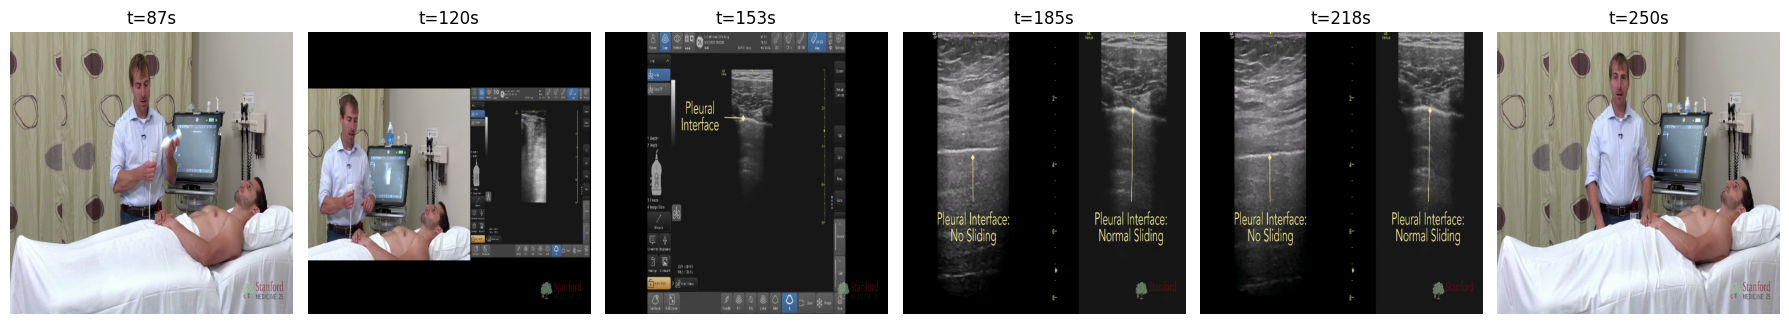

In [5]:
# Show 6 evenly sampled frames from the clip
frames = qa_generation.extract_clip_frames(
    str(VIDEO_PATH), clip['start'], clip['end'], num_frames=6
)
print(f'Extracted {len(frames)} frames')

fig, axes = plt.subplots(1, 6, figsize=(18, 4))
for ax, frame, t in zip(
    axes,
    frames,
    np.linspace(clip['start'], clip['end'], 6),
):
    rgb = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)
    ax.imshow(rgb)
    ax.set_title(f't={t:.0f}s')
    ax.axis('off')
plt.tight_layout()
plt.show()


## 2. Step 5a — Offline QA Generation

Generates 3 QA pairs (scene_description / fine_grained / knowledge) from the
full clip context. The generator is GPT-4o Vision.


In [6]:
# 2.1 — show the prompt that will be sent
print('--- SYSTEM PROMPT (qa_generation.QA_SYSTEM_PROMPT) ---')
print(qa_generation.QA_SYSTEM_PROMPT)


--- SYSTEM PROMPT (qa_generation.QA_SYSTEM_PROMPT) ---
You are a senior ultrasound instructor and medical education expert.

Given a set of video frames from an ultrasound teaching clip and the corresponding speech transcription, generate exactly THREE question-answer pairs (one of each required type).

IMPORTANT: These frames are from a VIDEO (shown in temporal order, Frame 1 is earliest, last frame is latest). The viewer is allowed to see the ENTIRE clip, so describe the whole process holistically.

Required QA Types (generate exactly one of each):
1. "scene_description"  — What happens in this clip from beginning to end? Describe the scanning workflow, anatomical structures revealed, and how the view evolves over time. Use temporal language ("first... then... finally...").
2. "fine_grained"       — Pick the most clinically salient visual detail in the clip and describe it precisely: anatomical landmarks visible, echogenicity patterns, probe orientation/positioning, depth/gain settin

In [7]:
# 2.2 — call GPT-4o (one API request)
asr_text   = clip.get('text', '')
video_type = clip.get('video_type', 'ultrasound_tutorial')
topic      = clip.get('topic', '')

t0 = time.time()
offline_qa = qa_generation.generate_qa_for_clip(
    frames=frames,
    asr_text=asr_text,
    video_type=video_type,
    topic=topic,
)
print(f'Got {len(offline_qa)} QA pairs in {time.time()-t0:.1f}s')


  GPT-4o: 6.2s | 2060 tokens
Got 3 QA pairs in 6.8s


In [8]:
# 2.3 — display offline QA pairs
df_offline = pd.DataFrame([
    {'type': q['type'],
     'question': q['question'],
     'answer': q['answer'],
     'timestamp_hint': q.get('timestamp_hint', '')}
    for q in offline_qa
])

for _, row in df_offline.iterrows():
    display(Markdown(f"### [{row['type']}]\n**Q:** {row['question']}\n\n**A:** {row['answer']}"))


### [scene_description]
**Q:** What happens in this clip from beginning to end?

**A:** First, the instructor explains the importance of patient positioning when using a linear probe to detect pneumothorax. The patient is positioned lying flat to allow air to rise to the highest part of the chest. The instructor places the probe across rib spaces to visualize the pleural interface. Initially, normal lung sliding is demonstrated, indicating no pneumothorax. Then, a comparison is made with a video showing absence of lung sliding, suggesting a potential pneumothorax.

### [fine_grained]
**Q:** What is the most clinically salient visual detail in the clip?

**A:** The most clinically salient detail is the visualization of the pleural interface as a bright white line between the ribs. In the normal lung, this line shows movement, described as 'ants on a log,' indicating lung sliding. In contrast, the absence of this movement in the comparison video suggests a lack of lung sliding, which is a key indicator of pneumothorax.

### [knowledge]
**Q:** What is the clinical significance of observing lung sliding in an ultrasound?

**A:** Observing lung sliding on ultrasound is significant because it indicates that the visceral and parietal pleura are in contact, ruling out pneumothorax. The presence of lung sliding has a high negative predictive value for pneumothorax, meaning if sliding is observed, pneumothorax is unlikely. However, the absence of lung sliding does not definitively confirm pneumothorax, as other conditions can also cause this finding, necessitating further diagnostic evaluation.

## 3. Step 5b — Streaming QA (single anchor)

Streaming generator is an **oracle**: sees both [SEEN] frames (clip_start →
query_time) **and** [FUTURE] frames (query_time → clip_end), plus the full ASR.

It must phrase the QUESTION as if only [SEEN] is available, but the ANSWER
may use SEEN+FUTURE as ground truth.


In [9]:
# 3.1 — set up anchor
query_time = clip['start'] + clip['duration'] * RATIO
print(f"Anchor: ratio={RATIO} → query_time = {query_time:.0f}s")
print(f"  [SEEN]   {clip['start']:.0f}s -> {query_time:.0f}s")
print(f"  [FUTURE] {query_time:.0f}s -> {clip['end']:.0f}s")


Anchor: ratio=0.5 → query_time = 169s
  [SEEN]   87s -> 169s
  [FUTURE] 169s -> 250s


SEEN: 3 frames    FUTURE: 3 frames


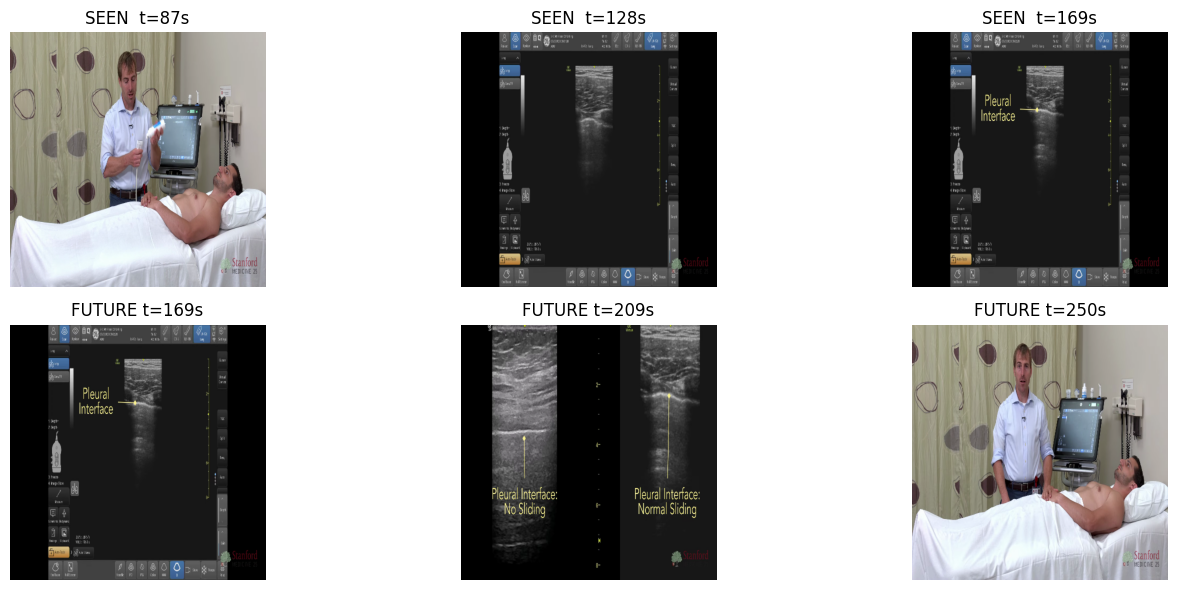

In [10]:
# 3.2 — extract SEEN + FUTURE frames and display
seen_frames = streaming_qa_generation.extract_clip_frames(
    str(VIDEO_PATH), clip['start'], query_time,
    num_frames=streaming_qa_generation.SEEN_FRAMES,
)
future_frames = streaming_qa_generation.extract_clip_frames(
    str(VIDEO_PATH), query_time, clip['end'],
    num_frames=streaming_qa_generation.FUTURE_FRAMES,
)
print(f'SEEN: {len(seen_frames)} frames    FUTURE: {len(future_frames)} frames')

fig, axes = plt.subplots(2, max(len(seen_frames), len(future_frames)), figsize=(15, 6))
for ax, frame, t in zip(
    axes[0], seen_frames,
    np.linspace(clip['start'], query_time, len(seen_frames)),
):
    ax.imshow(cv2.cvtColor(frame, cv2.COLOR_BGR2RGB))
    ax.set_title(f'SEEN  t={t:.0f}s')
    ax.axis('off')
for ax, frame, t in zip(
    axes[1], future_frames,
    np.linspace(query_time, clip['end'], len(future_frames)),
):
    ax.imshow(cv2.cvtColor(frame, cv2.COLOR_BGR2RGB))
    ax.set_title(f'FUTURE t={t:.0f}s')
    ax.axis('off')
plt.tight_layout()
plt.show()


In [11]:
# 3.3 — show the prompt template (placeholders not yet filled)
print('--- STREAMING QA PROMPT TEMPLATE ---')
print(streaming_qa_generation.STREAMING_QA_PROMPT[:2000] + '...')


--- STREAMING QA PROMPT TEMPLATE ---
You are a senior ultrasound instructor and medical education expert.

You are observing an ultrasound teaching clip. The clip runs from t={clip_start:.0f}s to t={clip_end:.0f}s.

The "query time" is t={current_time:.0f}s — this is the moment a learner pauses and asks a question while watching the video live.

I am giving you TWO sets of frames, in temporal order:

[SEEN] frames ({clip_start:.0f}s -> {current_time:.0f}s) — content the learner has already watched.
[FUTURE] frames ({current_time:.0f}s -> {clip_end:.0f}s) — content that comes AFTER the question, NOT visible to the learner.

You also have the FULL ASR transcript of the clip (no truncation):
"{full_asr}"

Clip topic: {topic}

Your job: write exactly TWO question-answer pairs (one of each required type).

Required types:
  1. "sonographer_intent"     — what the operator is trying to accomplish at this moment
  2. "next_action_guidance"   — what the sonographer should do next

CRITICAL writ

In [12]:
# 3.4 — call GPT-4o for this single anchor
t0 = time.time()
single_streaming = streaming_qa_generation.generate_streaming_qa(
    str(VIDEO_PATH), clip, ratio=RATIO,
)
print(f'Got {len(single_streaming)} QA pairs in {time.time()-t0:.1f}s')


    t=169s (ratio=0.5) | 3 SEEN + 3 FUTURE frames | 2.9s | 1874 tok
Got 2 QA pairs in 3.2s


In [13]:
# 3.5 — display the 2 streaming QA (intent + next_action)
for q in single_streaming:
    display(Markdown(
        f"### [{q['type']}] @ t={q['query_time']:.0f}s (ratio={q['ratio']})\n"
        f"**Q:** {q['question']}\n\n**A:** {q['answer']}"
    ))


### [sonographer_intent] @ t=169s (ratio=0.5)
**Q:** At this point, what is the operator trying to demonstrate with the ultrasound?

**A:** The operator is trying to demonstrate the presence or absence of lung sliding at the pleural interface to assess for a pneumothorax.

### [next_action_guidance] @ t=169s (ratio=0.5)
**Q:** Based on what we've seen so far, what should the sonographer do next?

**A:** The sonographer should proceed to show a video of what a pneumothorax would look like, highlighting the absence of lung sliding at the pleural interface.

## 5. Step 5c — Validation (single QA)

Audits ONE streaming QA pair using Gemini 2.5 Flash on OpenRouter.

**Validation rule (binary):**
- (1) QUESTION must be writable from [SEEN] only (no future leakage)
- (2) ANSWER must correspond to what is actually visible in [SEEN]+[FUTURE]
- `verdict = "pass"` if BOTH hold, else `"fail"`


In [14]:
# 5.1 — pick a streaming QA to validate
# (defaults to the second one from section 3 — usually next_action_guidance)
qa_to_validate = single_streaming[1] if len(single_streaming) > 1 else single_streaming[0]
print(f"Validating: [{qa_to_validate['type']}] @t={qa_to_validate['query_time']:.0f}s")
print(f"Q: {qa_to_validate['question']}")
print(f"A: {qa_to_validate['answer']}")


Validating: [next_action_guidance] @t=169s
Q: Based on what we've seen so far, what should the sonographer do next?
A: The sonographer should proceed to show a video of what a pneumothorax would look like, highlighting the absence of lung sliding at the pleural interface.


In [15]:
# 5.2 — show the validator prompt template
print('--- VALIDATOR PROMPT TEMPLATE ---')
print(qa_validator.VALIDATOR_PROMPT_TEMPLATE)


--- VALIDATOR PROMPT TEMPLATE ---
You are a strict validator for a streaming ultrasound QA benchmark.

A QA pair was generated for a streaming scenario at query time t={query_time:.0f}s
within a clip that runs from {clip_start:.0f}s to {clip_end:.0f}s.

Question: "{question}"
Answer:   "{answer}"
Type:     {qa_type}    (sonographer_intent or next_action_guidance)

I am showing you TWO sets of frames in temporal order:
[SEEN] frames   ({clip_start:.0f}s -> {query_time:.0f}s) — content the learner had access to when the question was asked.
[FUTURE] frames ({query_time:.0f}s -> {clip_end:.0f}s)   — content AFTER the question, which the learner had NOT seen.

Validation criteria — BOTH must hold for a "pass":

(1) QUESTION GROUNDING:
    The QUESTION must be writable using ONLY [SEEN] frames (and any ASR up to t={query_time:.0f}s).
    It must NOT reveal, reference, hint at, or assume any content that only appears in [FUTURE].

(2) ANSWER FAITHFULNESS:
    The ANSWER must correspond to wha

In [16]:
# 5.3 — call Gemini 2.5 Flash
t0 = time.time()
validation = qa_validator.validate_streaming_qa(
    qa_to_validate, str(VIDEO_PATH),
)
print(f'\nValidator finished in {time.time()-t0:.1f}s')

display(Markdown(f"""### Verdict: **`{validation['verdict']}`**

**Reason:** {validation['reason']}

*model: `{validation['validator_model']}`*"""))


      Gemini: 23.3s | 2196 tok | next_action_guidance @t=169s
      RAW: '```json {   "verdict": "pass",   "reason": "The question is grounded in the [SEEN] frames as the sonographer has just finished explaining the pleural interface and is about to move on to showing different lung conditions. The answer accurately describes the next action, which is to show a video comp'

Validator finished in 23.5s


### Verdict: **`pass`**

**Reason:** The question is grounded in the [SEEN] frames as the sonographer has just finished explaining the pleural interface and is about to move on to showing different lung conditions. The answer accurately describes the next action, which is to show a video comparing a pleural interface with no sliding (indicating pneumothorax) and one with normal sliding, as seen in the [FUTURE] frames. This directly follows the previous explanation of the pleural interface.

*model: `google/gemini-2.5-flash`*